<a href="https://colab.research.google.com/github/Mariano-14/notebooks/blob/main/Cuaderno%20creado%20el%2012-10-2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔧 Verificando GPU disponible...
GPU disponible: True
GPU en uso: Tesla T4
⚠️ Si no ves GPU, ve a: Entorno de ejecución → Cambiar tipo → T4 GPU\n
📦 Instalando Ultralytics (YOLOv8)...
✅ Instalación completada\n
📥 DESCARGANDO DATASET DESDE ROBOFLOW
🔑 INSTRUCCIONES:
1. Ve a tu proyecto en Roboflow
2. Haz clic en 'Export' → Formato: 'YOLOv8'
3. Copia el código que te proporciona (similar al de abajo)
4. Pega aquí tus credenciales:\n
loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 85.0%
Version export complete for yolov8 format
\n✅ Dataset descargado en: /content/Deteccion-restos-basura-con-ia-1
\n📊 Verificando estructura del dataset...
✅ Clases detectadas: ['Papel', 'Papel Aluminio', 'Plstico']
✅ Número de clases: 3
✅ Imágenes de entrenamiento: 8
✅ Imágenes de validación: 1
\n🤖 Cargando modelo YOLOv8 Nano pre-entrenado...
📝 Nota: YOLOv8n es ligero y rápido, ideal para empezar
✅ Modelo cargado con éxito\n
⚙️ CONFIGURACIÓN DEL ENTRENAMIENTO
Époc

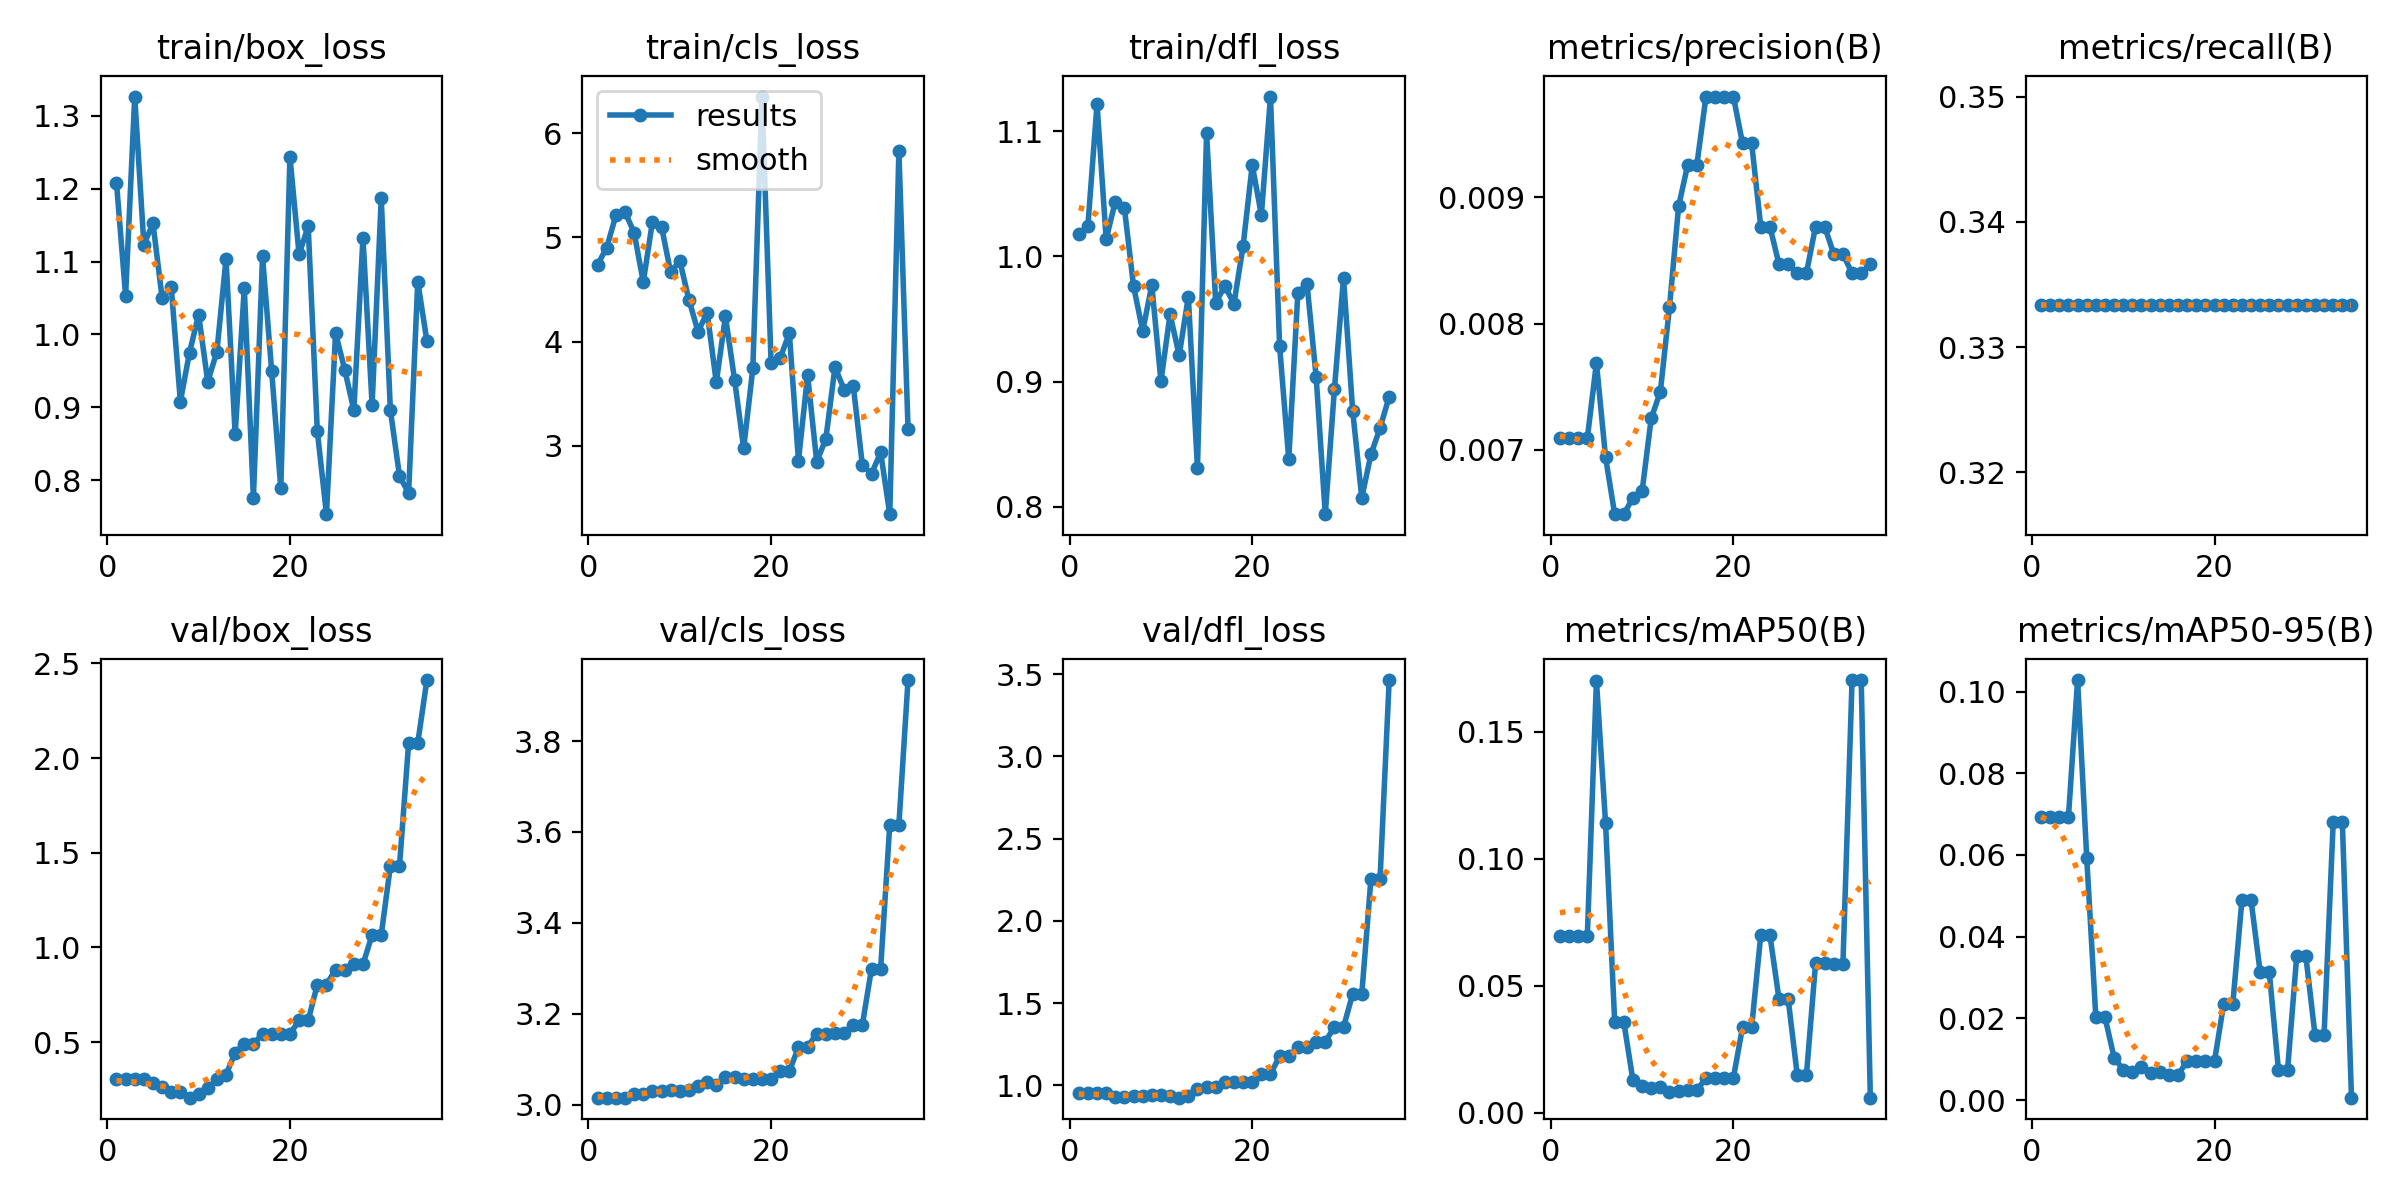

\n🔢 Matriz de confusión:


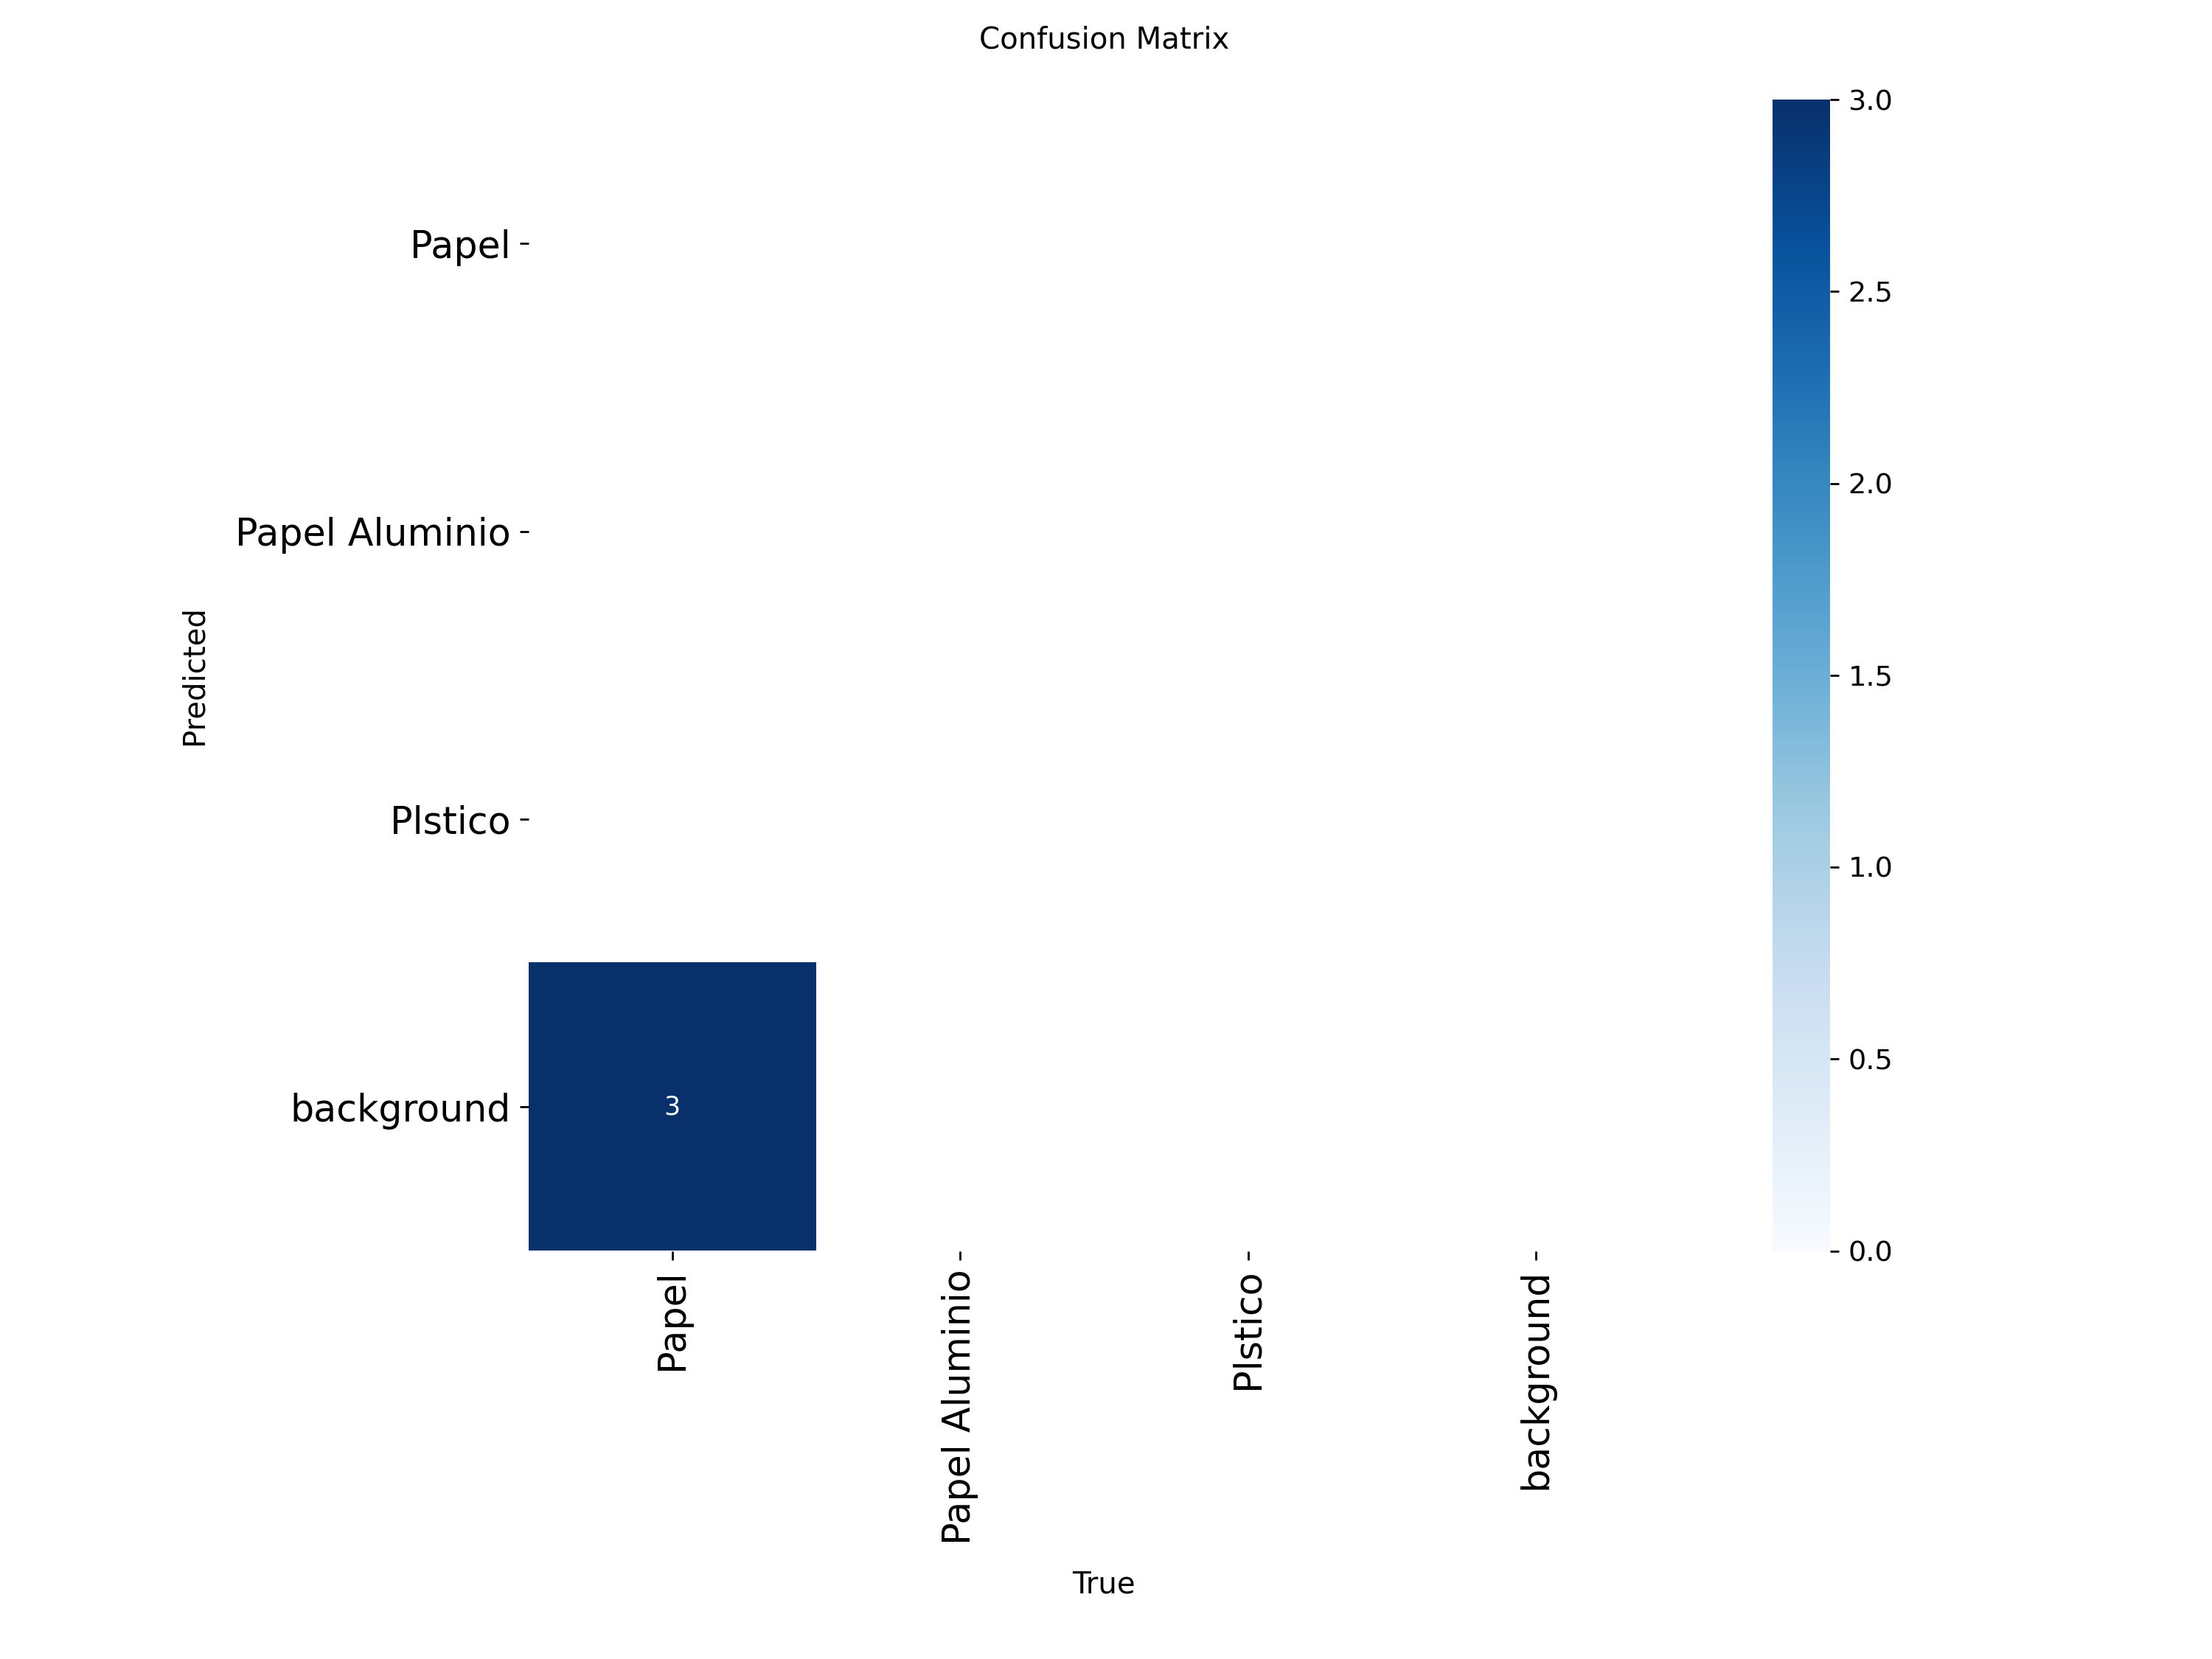

\n🖼️ Ejemplos de predicciones en el conjunto de validación:


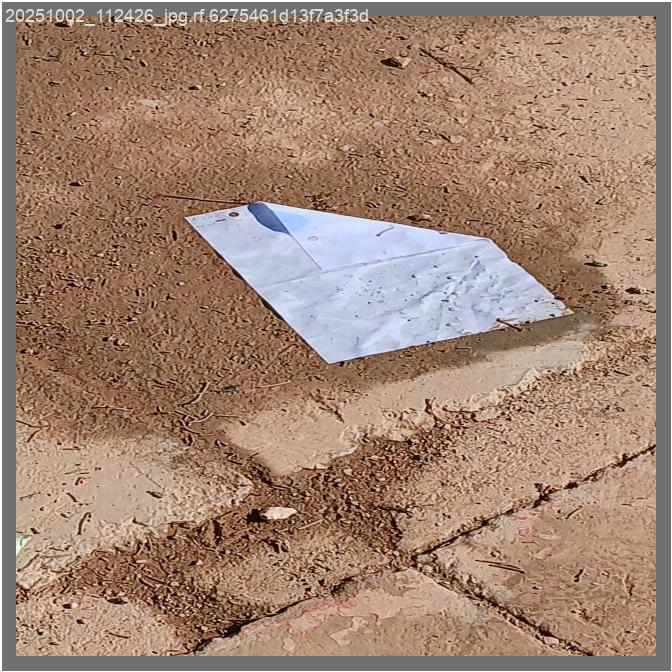

\n🧪 EVALUANDO EL MODELO EN EL CONJUNTO DE PRUEBA...
Ultralytics 8.3.211 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1537.8±0.0 MB/s, size: 113.4 KB)
val: Scanning /content/Deteccion-restos-basura-con-ia-1/test/labels... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 650.1it/s 0.0s
val: New cache created: /content/Deteccion-restos-basura-con-ia-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 8.1it/s 0.1s
                   all          1          1     0.0069          1      0.332      0.199
                 Papel          1          1     0.0069          1      0.332      0.199
Speed: 0.5ms preprocess, 100.3ms inference, 0.0ms loss, 6.4ms postprocess per image
Results saved to /content/runs/detect/val
\n📊 MÉTRICAS FINALES:
mAP50 (precisión media)

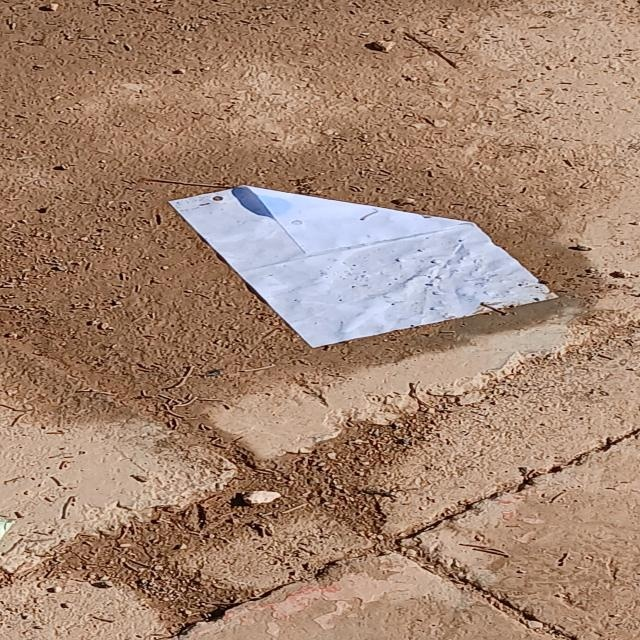

\n📦 EXPORTANDO MODELO PARA PRODUCCIÓN...
Exportando a ONNX (recomendado para producción)...
Ultralytics 8.3.211 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/residuos_cantina_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 4.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success ✅ 6.1s, saved as 'runs/detect/residuos_cantina_v1/weights/best.onnx' (11.7 MB)

Export complete (6.4s)
Results saved to /content/runs/detect/residuos_canti

In [ ]:
# ============================================================================
# CUADERNO COMPLETO: DETECCIÓN DE RESIDUOS ESCOLARES CON YOLOv8
# ============================================================================
# Proyecto: Reconocimiento de basura en cantina escolar
# Dataset inicial: 200 imágenes
# Método: Transfer Learning con YOLOv8
# ============================================================================

# ============================================================================
# PASO 1: CONFIGURACIÓN INICIAL Y VERIFICACIÓN DE GPU
# ============================================================================
print("🔧 Verificando GPU disponible...")
import torch
print(f"GPU disponible: {torch.cuda.is_available()}")
print(f"GPU en uso: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("⚠️ Si no ves GPU, ve a: Entorno de ejecución → Cambiar tipo → T4 GPU\\n")

# ============================================================================
# PASO 2: INSTALACIÓN DE DEPENDENCIAS
# ============================================================================
print("📦 Instalando Ultralytics (YOLOv8)...")
!pip install ultralytics roboflow -q

from ultralytics import YOLO
from roboflow import Roboflow
import os
from IPython.display import Image, display
import shutil

print("✅ Instalación completada\\n")

# ============================================================================
# PASO 3: IMPORTAR DATASET DESDE ROBOFLOW
# ============================================================================
print("📥 DESCARGANDO DATASET DESDE ROBOFLOW")
print("=" * 60)
print("🔑 INSTRUCCIONES:")
print("1. Ve a tu proyecto en Roboflow")
print("2. Haz clic en 'Export' → Formato: 'YOLOv8'")
print("3. Copia el código que te proporciona (similar al de abajo)")
print("4. Pega aquí tus credenciales:\\n")
print("=" * 60)

# 🔴 REEMPLAZA ESTOS VALORES CON LOS TUYOS DE ROBOFLOW:
rf = Roboflow(api_key="HA6rr0BCggnlRz0L4iVQ") # Reemplaza con tu API key
project = rf.workspace("mariano-f0rix").project("deteccion-restos-basura-con-ia-oc739") # Reemplaza
dataset = project.version(1).download("yolov8")  # Versión de tu dataset

print(f"\\n✅ Dataset descargado en: {dataset.location}")

# ============================================================================
# PASO 4: VERIFICAR ESTRUCTURA DEL DATASET
# ============================================================================
print("\\n📊 Verificando estructura del dataset...")
data_yaml_path = f"{dataset.location}/data.yaml"

# Leer el archivo data.yaml para ver las clases
import yaml
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print(f"✅ Clases detectadas: {data_config['names']}")
print(f"✅ Número de clases: {data_config['nc']}")
print(f"✅ Imágenes de entrenamiento: {len(os.listdir(f'{dataset.location}/train/images'))}")
print(f"✅ Imágenes de validación: {len(os.listdir(f'{dataset.location}/valid/images'))}")

# ============================================================================
# PASO 5: CARGAR MODELO PRE-ENTRENADO (TRANSFER LEARNING)
# ============================================================================
print("\\n🤖 Cargando modelo YOLOv8 Nano pre-entrenado...")
print("📝 Nota: YOLOv8n es ligero y rápido, ideal para empezar")

model = YOLO('yolov8n.pt')  # Descarga automáticamente el modelo pre-entrenado
print("✅ Modelo cargado con éxito\\n")

# ============================================================================
# PASO 6: CONFIGURACIÓN DEL ENTRENAMIENTO
# ============================================================================
print("⚙️ CONFIGURACIÓN DEL ENTRENAMIENTO")
print("=" * 60)

# Parámetros recomendados para dataset pequeño (200 imágenes)
EPOCHS = 150          # Épocas de entrenamiento
IMG_SIZE = 640        # Tamaño de imagen (640 es estándar)
BATCH_SIZE = 16       # Ajustar según memoria GPU (8, 16 o 32)
PATIENCE = 30         # Paciencia para early stopping
LEARNING_RATE = 0.01  # Tasa de aprendizaje

print(f"Épocas: {EPOCHS}")
print(f"Tamaño de imagen: {IMG_SIZE}px")
print(f"Batch size: {BATCH_SIZE}")
print(f"Paciencia (early stopping): {PATIENCE}")
print(f"Learning rate: {LEARNING_RATE}")
print("=" * 60 + "\\n")

# ============================================================================
# PASO 7: ENTRENAR EL MODELO
# ============================================================================
print("🚀 INICIANDO ENTRENAMIENTO...")
print("⏱️ Esto puede tomar 30-60 minutos dependiendo de tu GPU\\n")

results = model.train(
    data=data_yaml_path,           # Ruta al archivo data.yaml
    epochs=EPOCHS,                 # Número de épocas
    imgsz=IMG_SIZE,                # Tamaño de imagen
    batch=BATCH_SIZE,              # Tamaño de lote
    patience=PATIENCE,             # Early stopping
    save=True,                     # Guardar checkpoints
    device=0,                      # GPU (0) o CPU ('cpu')
    project='runs/detect',         # Directorio de salida
    name='residuos_cantina_v1',    # Nombre del experimento
    exist_ok=True,                 # Sobrescribir si existe
    pretrained=True,               # Usar pesos pre-entrenados
    optimizer='auto',              # Optimizador automático
    verbose=True,                  # Mostrar progreso
    seed=42,                       # Semilla para reproducibilidad
    deterministic=True,            # Resultados determinísticos
    single_cls=False,              # Multi-clase
    rect=False,                    # Entrenamiento rectangular
    cos_lr=True,                   # Cosine learning rate scheduler
    close_mosaic=10,               # Desactivar mosaic últimas 10 épocas
    amp=True,                      # Automatic Mixed Precision
    lr0=LEARNING_RATE,             # Learning rate inicial
    lrf=0.01,                      # Learning rate final
    momentum=0.937,                # Momentum
    weight_decay=0.0005,           # Weight decay
    warmup_epochs=3,               # Épocas de calentamiento
    warmup_momentum=0.8,           # Momentum de calentamiento
    box=7.5,                       # Box loss gain
    cls=0.5,                       # Cls loss gain
    dfl=1.5,                       # DFL loss gain
    hsv_h=0.015,                   # Augmentation: HSV-Hue
    hsv_s=0.7,                     # Augmentation: HSV-Saturation
    hsv_v=0.4,                     # Augmentation: HSV-Value
    degrees=0.0,                   # Augmentation: Rotación
    translate=0.1,                 # Augmentation: Traslación
    scale=0.5,                     # Augmentation: Escala
    shear=0.0,                     # Augmentation: Shear
    perspective=0.0,               # Augmentation: Perspectiva
    flipud=0.0,                    # Augmentation: Flip vertical
    fliplr=0.5,                    # Augmentation: Flip horizontal
    mosaic=1.0,                    # Augmentation: Mosaic
    mixup=0.0,                     # Augmentation: Mixup
    copy_paste=0.0                 # Augmentation: Copy-paste
)

print("\\n🎉 ¡ENTRENAMIENTO COMPLETADO!\\n")

# ============================================================================
# PASO 8: VISUALIZAR RESULTADOS DEL ENTRENAMIENTO
# ============================================================================
print("📊 VISUALIZANDO RESULTADOS...")

# Ruta donde se guardaron los resultados
results_path = 'runs/detect/residuos_cantina_v1'

# Mostrar curvas de entrenamiento
print("\\n📈 Curvas de entrenamiento (pérdida y métricas):")
display(Image(filename=f'{results_path}/results.png'))

# Mostrar matriz de confusión
print("\\n🔢 Matriz de confusión:")
display(Image(filename=f'{results_path}/confusion_matrix.png'))

# Mostrar ejemplos de predicciones en validación
print("\\n🖼️ Ejemplos de predicciones en el conjunto de validación:")
display(Image(filename=f'{results_path}/val_batch0_pred.jpg'))

# ============================================================================
# PASO 9: EVALUAR EL MODELO
# ============================================================================
print("\\n🧪 EVALUANDO EL MODELO EN EL CONJUNTO DE PRUEBA...")

# Cargar el mejor modelo entrenado
best_model = YOLO(f'{results_path}/weights/best.pt')

# Validar en el conjunto de test
metrics = best_model.val(data=data_yaml_path, split='test')

print("\\n📊 MÉTRICAS FINALES:")
print("=" * 60)
print(f"mAP50 (precisión media): {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precisión: {metrics.box.mp:.3f}")
print(f"Recall: {metrics.box.mr:.3f}")
print("=" * 60)

# ============================================================================
# PASO 10: PROBAR EL MODELO CON IMÁGENES NUEVAS
# ============================================================================
print("\\n🔍 PROBANDO EL MODELO CON IMÁGENES DE VALIDACIÓN...")

# Predecir en algunas imágenes de validación
test_images = os.listdir(f'{dataset.location}/valid/images')[:3]  # Primeras 3 imágenes

for img_name in test_images:
    img_path = f'{dataset.location}/valid/images/{img_name}'
    results = best_model.predict(
        source=img_path,
        conf=0.25,        # Confianza mínima
        iou=0.45,         # IoU para NMS
        save=True,        # Guardar resultados
        project='runs/detect',
        name='predicciones_test',
        exist_ok=True
    )

print("\\n✅ Predicciones guardadas en: runs/detect/predicciones_test/")

# Mostrar una predicción de ejemplo
pred_images = os.listdir('runs/detect/predicciones_test/')
if pred_images:
    print("\\n🖼️ Ejemplo de predicción:")
    display(Image(filename=f'runs/detect/predicciones_test/{pred_images[0]}'))

# ============================================================================
# PASO 11: EXPORTAR MODELO PARA PRODUCCIÓN
# ============================================================================
print("\\n📦 EXPORTANDO MODELO PARA PRODUCCIÓN...")

# Exportar a diferentes formatos
print("Exportando a ONNX (recomendado para producción)...")
best_model.export(format='onnx')

print("\\n✅ Modelo exportado. Archivos disponibles:")
print(f"  - PyTorch: {results_path}/weights/best.pt")
print(f"  - ONNX: {results_path}/weights/best.onnx")

# ============================================================================
# PASO 12: GUARDAR EN GOOGLE DRIVE (OPCIONAL)
# ============================================================================
print("\\n💾 ¿DESEAS GUARDAR LOS RESULTADOS EN GOOGLE DRIVE?")
print("Descomenta las siguientes líneas y ejecuta:\\n")

# from google.colab import drive
# drive.mount('/content/drive')
#
# # Copiar resultados a Drive
# drive_path = '/content/drive/MyDrive/modelo_residuos_cantina'
# shutil.copytree(results_path, drive_path, dirs_exist_ok=True)
# print(f"✅ Resultados guardados en: {drive_path}")

# ============================================================================
# PASO 13: INSTRUCCIONES PARA USAR EL MODELO
# ============================================================================
print("\\n" + "="*60)
print("🎓 CÓMO USAR TU MODELO ENTRENADO")
print("="*60)
print("""
1. CARGAR EL MODELO:
   from ultralytics import YOLO
   model = YOLO('runs/detect/residuos_cantina_v1/weights/best.pt')

2. HACER PREDICCIONES:
   results = model.predict('imagen.jpg', conf=0.25)
   results[0].show()  # Mostrar imagen con detecciones

3. OBTENER COORDENADAS Y CLASES:
   for result in results:
       boxes = result.boxes
       for box in boxes:
           clase = box.cls
           confianza = box.conf
           coordenadas = box.xyxy

4. ENTRENAR CON MÁS IMÁGENES EN EL FUTURO:
   - Añade nuevas imágenes a Roboflow
   - Genera nueva versión del dataset
   - Vuelve a ejecutar este cuaderno desde el PASO 3
   - El modelo mejorará automáticamente

5. PRÓXIMOS PASOS:
   ✅ Probar el modelo en la cantina real
   ✅ Identificar qué clases detecta mal
   ✅ Recolectar más imágenes de esos casos
   ✅ Re-entrenar con 500+ imágenes
   ✅ Considerar YOLOv8s o YOLOv8m para mayor precisión
""")
print("="*60)

print("\\n🎉 ¡PROYECTO COMPLETADO CON ÉXITO!")
print("💡 Recuerda: Este es tu primer modelo. Mejorará con más datos.")
print("📧 Si tienes dudas, revisa la documentación: https://docs.ultralytics.com/")